In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
n_samples = 100
x = np.random.normal(0, 1, n_samples)  # Первый признак
y = 2 * x + np.random.normal(0, 0.5, n_samples)  # Второй признак (коррелирован с первым)

X = np.column_stack((x, y))

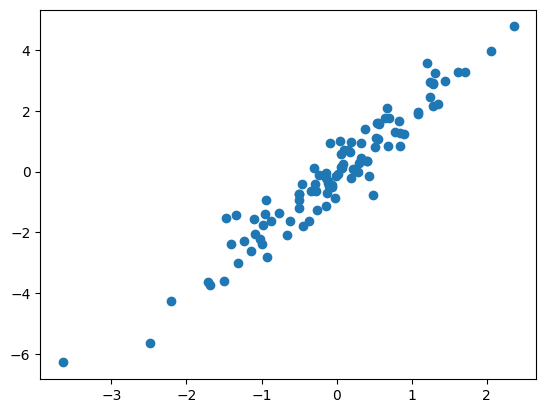

In [3]:
plt.scatter(x, y)
plt.show()

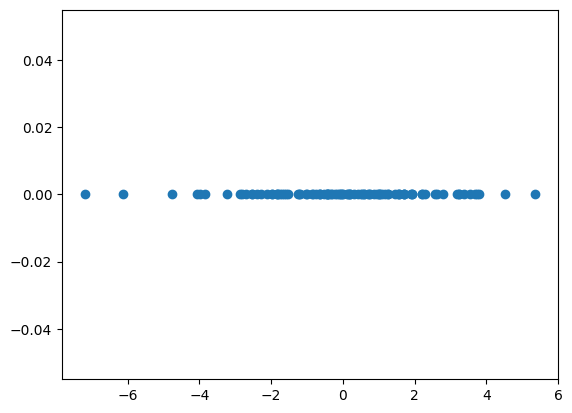

In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 0]))

In [5]:
print(f"Главная компонента (направление): {pca.components_}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")

Главная компонента (направление): [[0.43284452 0.90146859]]
Объясненная дисперсия: [0.98821418]


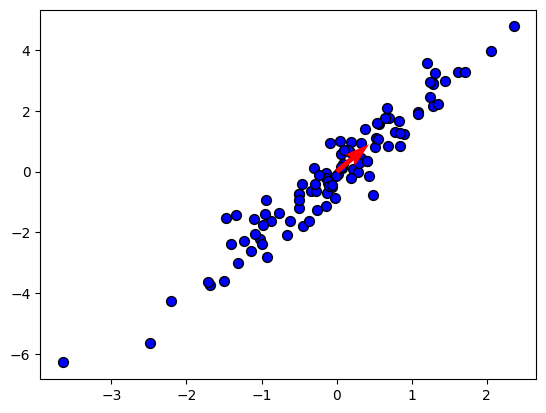

In [6]:
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
pc1_direction = pca.components_[0]
plt.quiver(0, 0, pc1_direction[0], pc1_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

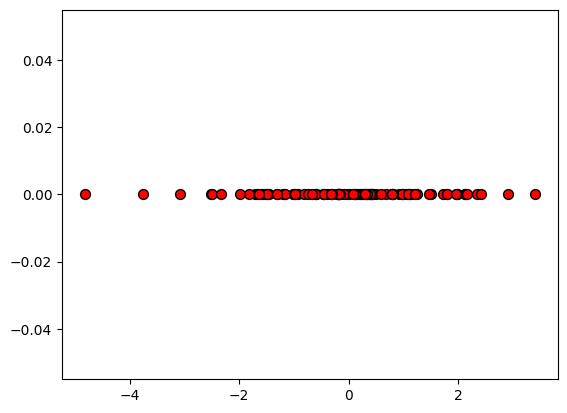

In [8]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca, np.zeros_like(X_pca), c='red', edgecolor='k', s=50)

In [9]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
X.shape

(569, 30)

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)  # Уменьшаем до 2 компонент
X_pca = pca.fit_transform(X_scaled)

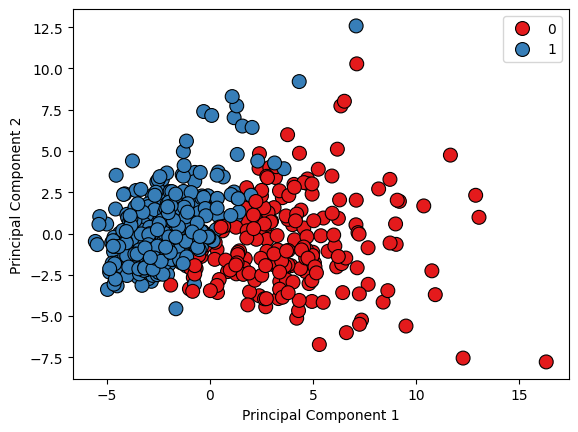

In [11]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', edgecolor='k', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [12]:
print(f"Главная компонента (направление): {pca.components_}")

Главная компонента (направление): [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


In [13]:
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182]
Суммарная объясненная дисперсия: 0.63


In [14]:
n_components_range = range(1, 31)
explained_variance = []

In [15]:
for n in n_components_range:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

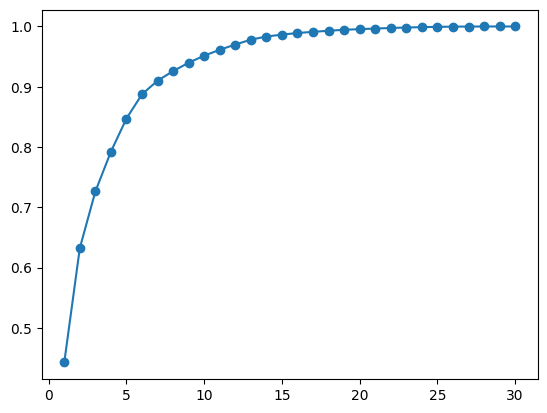

In [16]:
plt.plot(n_components_range, explained_variance, marker='o')
plt.show()

In [17]:
pca = PCA(n_components=7)  # Уменьшаем до 7 компонент
X_pca = pca.fit_transform(X_scaled)

# Объясненная дисперсия
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]
Суммарная объясненная дисперсия: 0.91


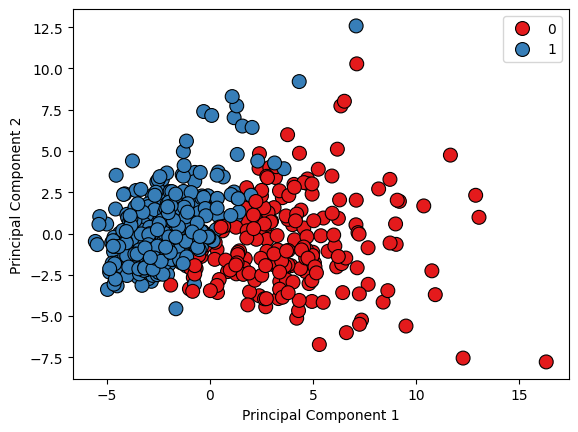

In [18]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', edgecolor='k', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show() # identical to prev one

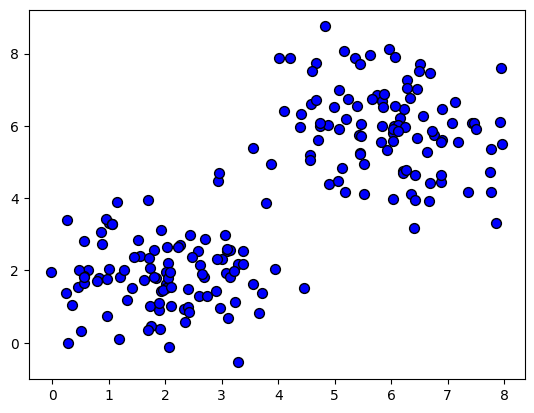

In [28]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
plt.show()

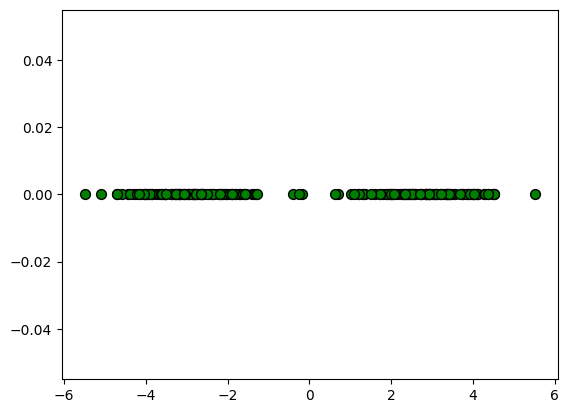

In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)
plt.scatter(X_lda, np.zeros_like(X_lda), c='green', edgecolor='k', s=50)
plt.show()

In [31]:
print(f"Коэффициенты LDA: {lda.coef_}")

Коэффициенты LDA: [[9.68304004 8.95248703]]


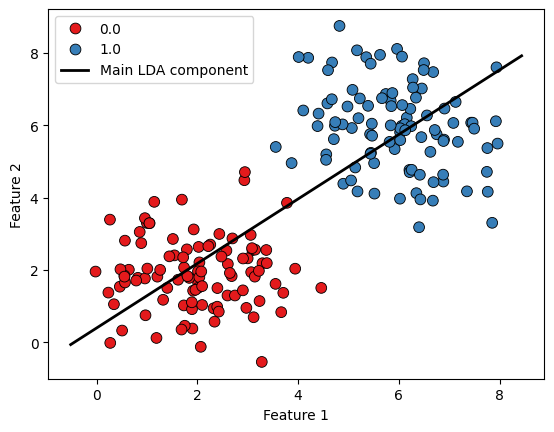

In [33]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k", s=60)

lda_direction = lda.coef_[0] / scaler.scale_
lda_direction = lda_direction / np.linalg.norm(lda_direction)

center = X.mean(axis=0)
t = np.linspace(-6, 6, 200)
line = center + np.outer(t, lda_direction)

plt.plot(line[:, 0], line[:, 1], color="black", linewidth=2, label="Main LDA component")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [35]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=200, random_state=170, centers=2)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation) 

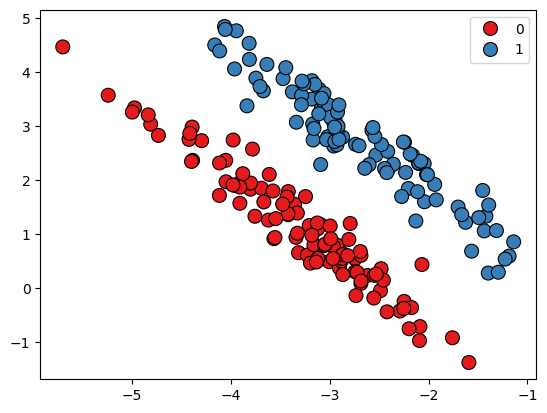

In [38]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1', edgecolor='k', s=100)
plt.show()

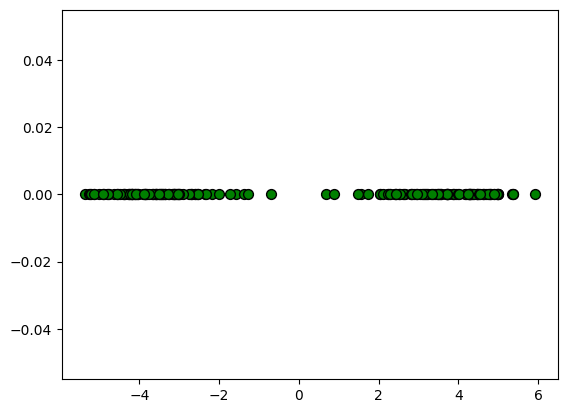

In [39]:
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)
plt.scatter(X_lda, np.zeros_like(X_lda), c='green', edgecolor='k', s=50)
plt.show()

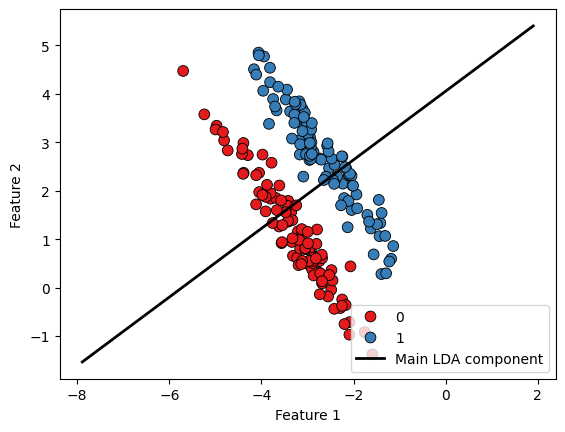

In [40]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k", s=60)

lda_direction = lda.coef_[0] / scaler.scale_
lda_direction = lda_direction / np.linalg.norm(lda_direction)

center = X.mean(axis=0)
t = np.linspace(-6, 6, 200)
line = center + np.outer(t, lda_direction)

plt.plot(line[:, 0], line[:, 1], color="black", linewidth=2, label="Main LDA component")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

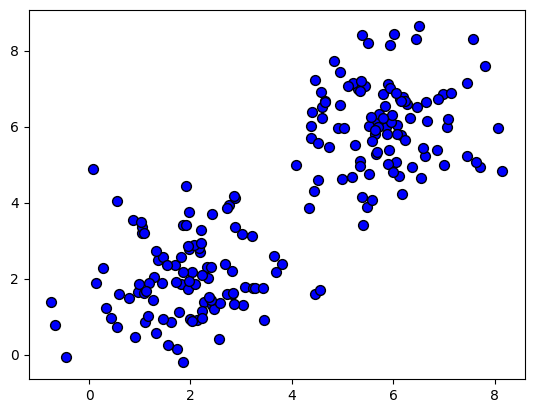

In [46]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
plt.show()

In [47]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=1, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

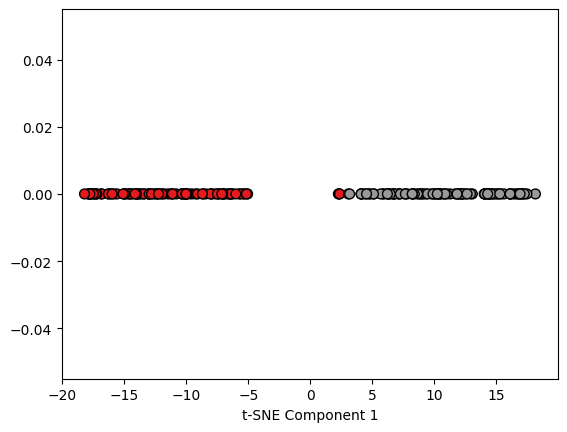

In [50]:
plt.scatter(X_tsne[:, 0], np.zeros_like(X_tsne[:, 0]), c=y, cmap='Set1', edgecolor='k', s=50)
plt.xlabel('t-SNE Component 1')
plt.ylabel('')
plt.show()

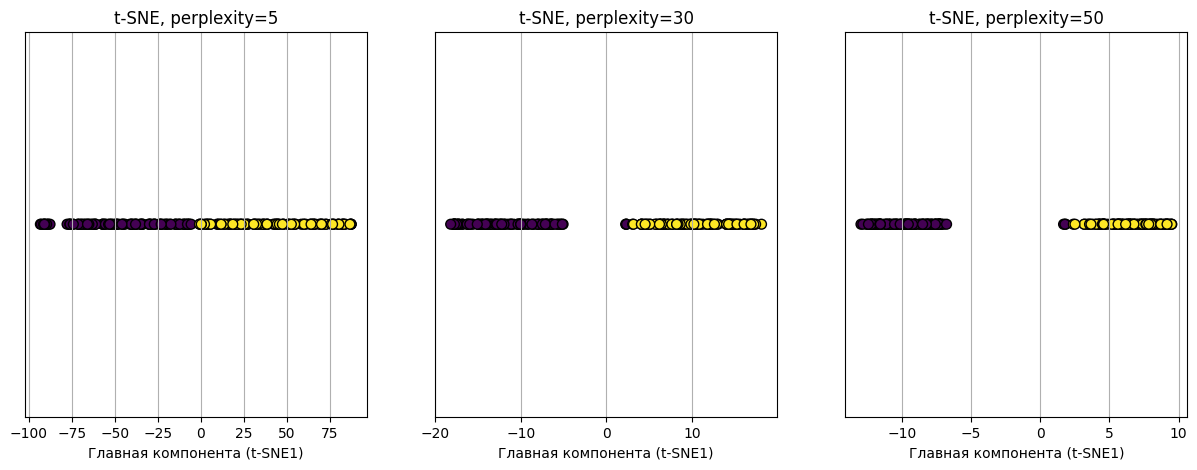

In [53]:
perplexity_values = [5, 30, 50]
plt.figure(figsize=(15, 5))
for i, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=1, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(f't-SNE, perplexity={perplexity}')
    plt.xlabel('Главная компонента (t-SNE1)')
    plt.yticks([])
    plt.grid(True)

In [59]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

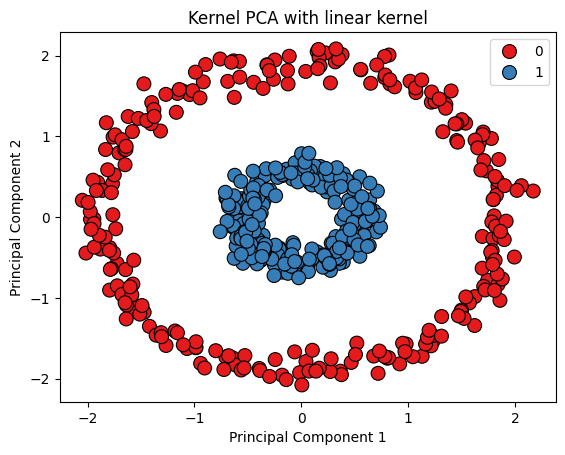

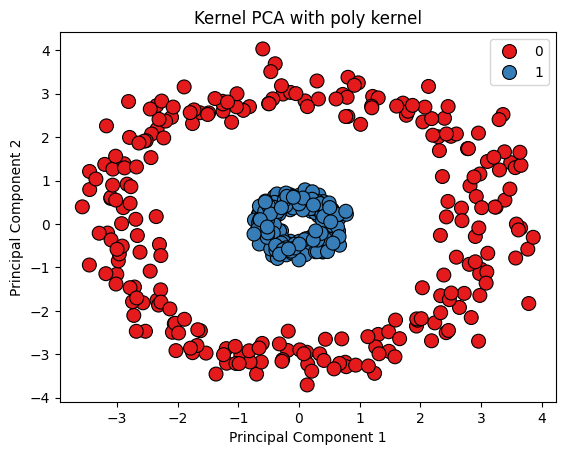

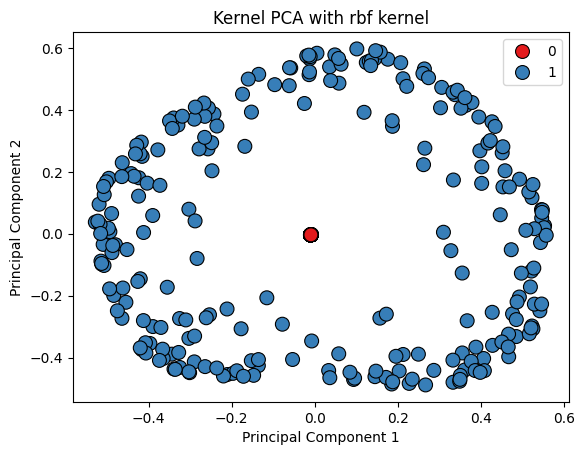

In [61]:
from sklearn.decomposition import KernelPCA
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    kpca = KernelPCA(n_components=2, kernel=kernel, gamma=10 if kernel == 'rbf' else None)
    X_kpca = kpca.fit_transform(X_scaled)
    X_scaled = scaler.fit_transform(X)
    X_kpca = kpca.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_kpca[:, 0],
        y=X_kpca[:, 1],
        hue=y,
        palette='Set1',
        edgecolor='k',
        s=100
    )
    plt.title(f'Kernel PCA with {kernel} kernel')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

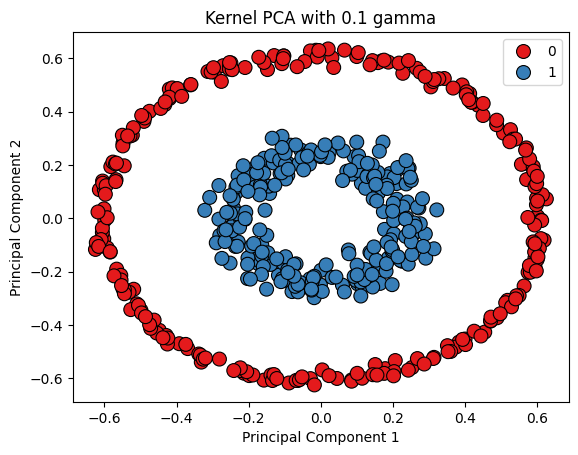

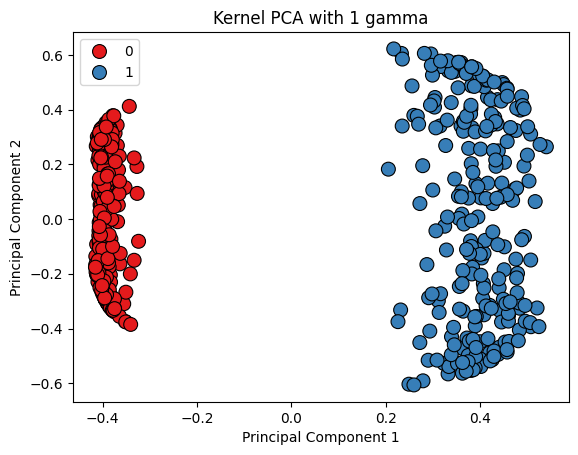

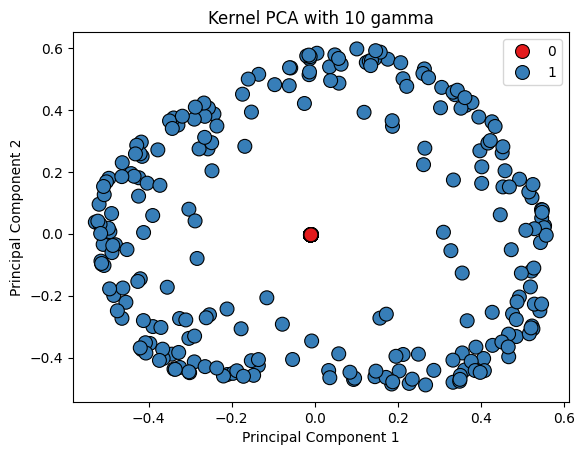

In [62]:
gamma_values = [0.1, 1, 10]
for gamma in gamma_values:
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma)
    X_kpca = kpca.fit_transform(X_scaled)
    X_scaled = scaler.fit_transform(X)
    X_kpca = kpca.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_kpca[:, 0],
        y=X_kpca[:, 1],
        hue=y,
        palette='Set1',
        edgecolor='k',
        s=100
    )
    plt.title(f'Kernel PCA with {gamma} gamma')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

# EXTRA TASKS

# 1

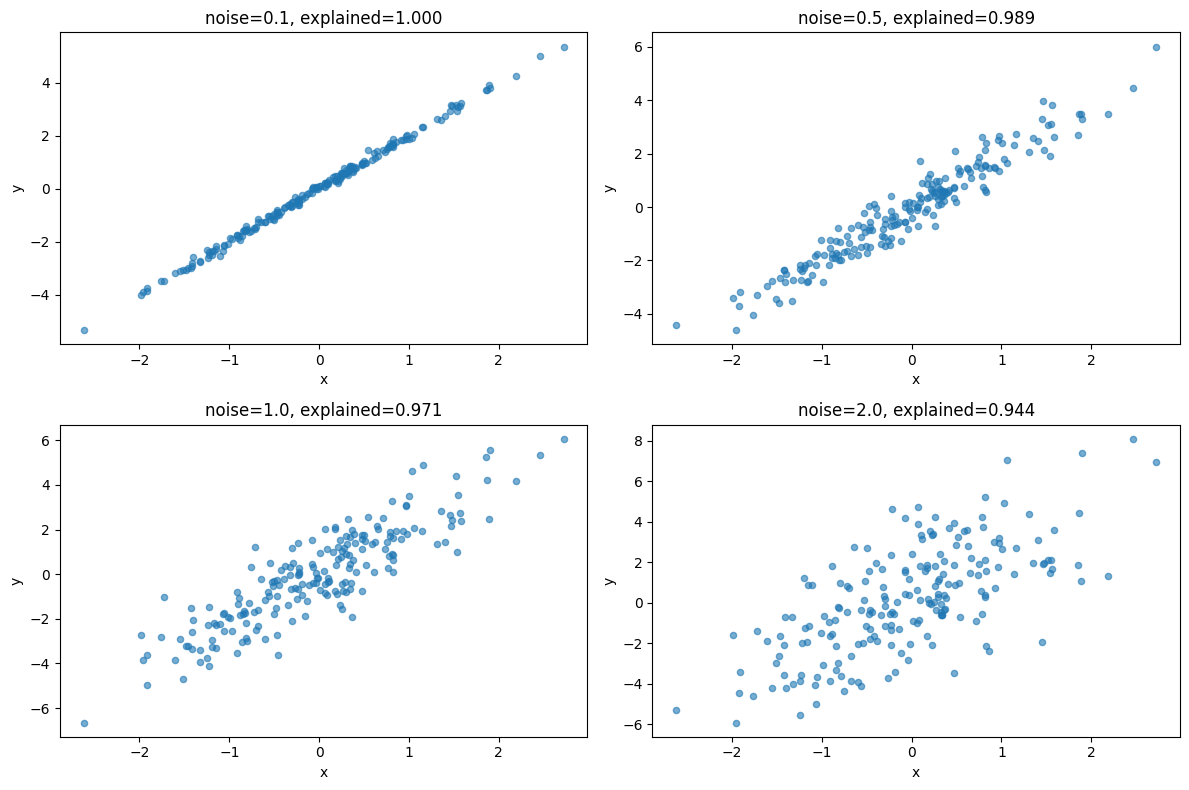

In [63]:
np.random.seed(42)
n_samples = 200
x = np.random.normal(0, 1, n_samples)
noise_levels = [0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, noise in zip(axes, noise_levels):
    y = 2 * x + np.random.normal(0, noise, n_samples)
    X_noise = np.column_stack((x, y))

    pca_noise = PCA(n_components=1)
    pca_noise.fit(X_noise)

    ax.scatter(X_noise[:, 0], X_noise[:, 1], alpha=0.6, s=20)
    ax.set_title(f"noise={noise}, explained={pca_noise.explained_variance_ratio_[0]:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

# 2

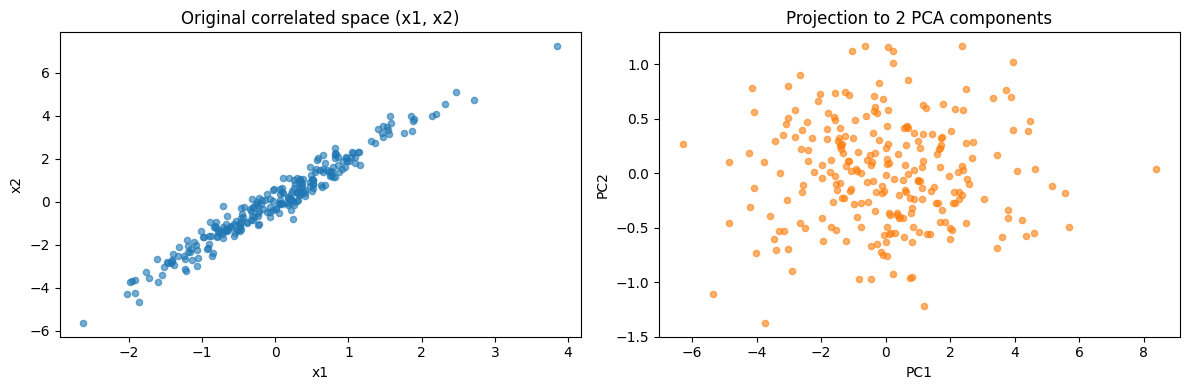

explained variance ratio: [0.95197352 0.0441522 ]
total explained variance: 0.9961


In [65]:
np.random.seed(42)
n_samples = 250
x1 = np.random.normal(0, 1, n_samples)
x2 = 2.0 * x1 + np.random.normal(0, 0.4, n_samples)
x3 = -1.2 * x1 + 0.8 * x2 + np.random.normal(0, 0.4, n_samples)

X3 = np.column_stack((x1, x2, x3))

pca3 = PCA(n_components=2)
X3_pca = pca3.fit_transform(X3)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(x1, x2, alpha=0.6, s=20)
ax[0].set_title("Original correlated space (x1, x2)")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")

ax[1].scatter(X3_pca[:, 0], X3_pca[:, 1], alpha=0.6, s=20, c="tab:orange")
ax[1].set_title("Projection to 2 PCA components")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

print("explained variance ratio:", pca3.explained_variance_ratio_)
print("total explained variance:", pca3.explained_variance_ratio_.sum().round(4))

# 3

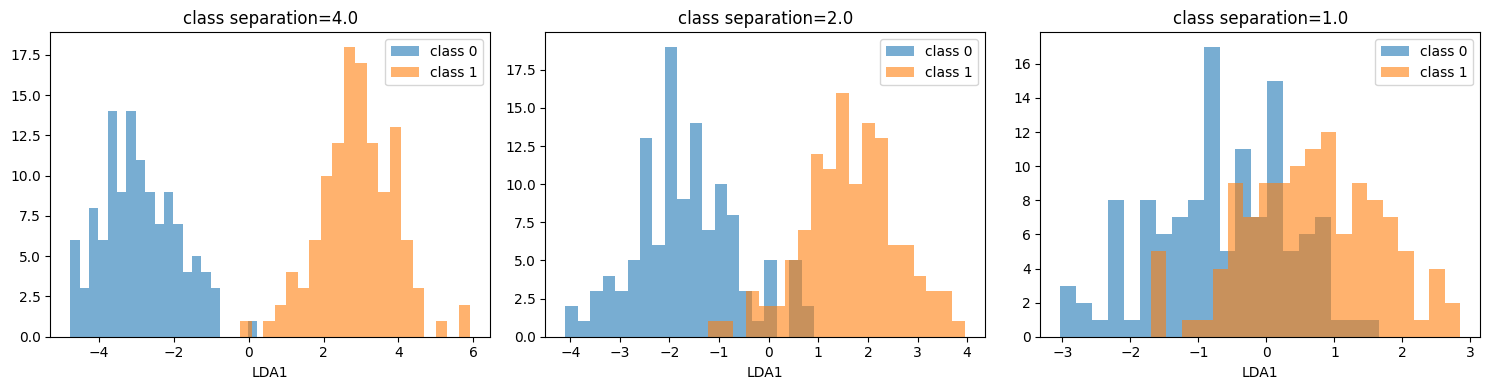

In [66]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

np.random.seed(42)
n_samples = 120

separations = [4.0, 2.0, 1.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, sep in zip(axes, separations):
    c1 = np.random.normal(loc=[0, 0], scale=1.0, size=(n_samples, 2))
    c2 = np.random.normal(loc=[sep, sep], scale=1.0, size=(n_samples, 2))
    X_sep = np.vstack([c1, c2])
    y_sep = np.array([0] * n_samples + [1] * n_samples)

    lda_sep = LDA(n_components=1)
    X_lda_sep = lda_sep.fit_transform(X_sep, y_sep).ravel()

    ax.hist(X_lda_sep[y_sep == 0], bins=20, alpha=0.6, label="class 0")
    ax.hist(X_lda_sep[y_sep == 1], bins=20, alpha=0.6, label="class 1")
    ax.set_title(f"class separation={sep}")
    ax.set_xlabel("LDA1")
    ax.legend()

plt.tight_layout()
plt.show()

# 4

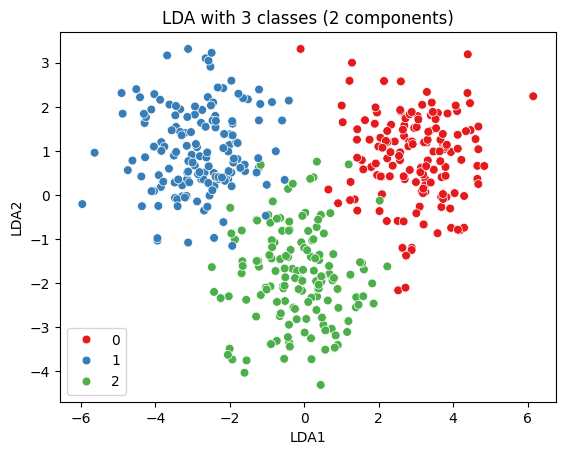

LDA explained_variance_ratio_: [0.76729313 0.23270687]


In [67]:
from sklearn.datasets import make_blobs

X3c, y3c = make_blobs(
    n_samples=450,
    centers=[(-2, -2), (2, 2), (2, -2)],
    cluster_std=[1.0, 1.0, 1.0],
    random_state=42
)

lda_2d = LDA(n_components=2)
X3c_lda = lda_2d.fit_transform(X3c, y3c)

sns.scatterplot(x=X3c_lda[:, 0], y=X3c_lda[:, 1], hue=y3c, palette="Set1", s=40)
plt.title("LDA with 3 classes (2 components)")
plt.xlabel("LDA1")
plt.ylabel("LDA2")
plt.show()

print("LDA explained_variance_ratio_:", lda_2d.explained_variance_ratio_)

# 5

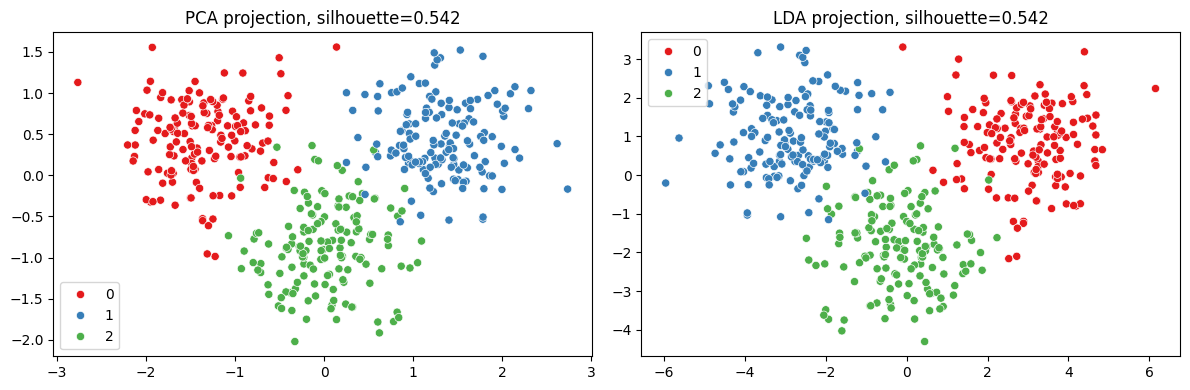

Better class separation on this dataset: PCA


In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

scaler_cmp = StandardScaler()
X_cmp = scaler_cmp.fit_transform(X3c)

pca_cmp = PCA(n_components=2, random_state=42)
X_cmp_pca = pca_cmp.fit_transform(X_cmp)

lda_cmp = LDA(n_components=2)
X_cmp_lda = lda_cmp.fit_transform(X_cmp, y3c)

sil_pca = silhouette_score(X_cmp_pca, y3c)
sil_lda = silhouette_score(X_cmp_lda, y3c)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=X_cmp_pca[:, 0], y=X_cmp_pca[:, 1], hue=y3c, palette="Set1", s=35, ax=ax[0])
ax[0].set_title(f"PCA projection, silhouette={sil_pca:.3f}")

sns.scatterplot(x=X_cmp_lda[:, 0], y=X_cmp_lda[:, 1], hue=y3c, palette="Set1", s=35, ax=ax[1])
ax[1].set_title(f"LDA projection, silhouette={sil_lda:.3f}")

plt.tight_layout()
plt.show()

better = "LDA" if sil_lda > sil_pca else "PCA"
print(f"Better class separation on this dataset: {better}")

# 6

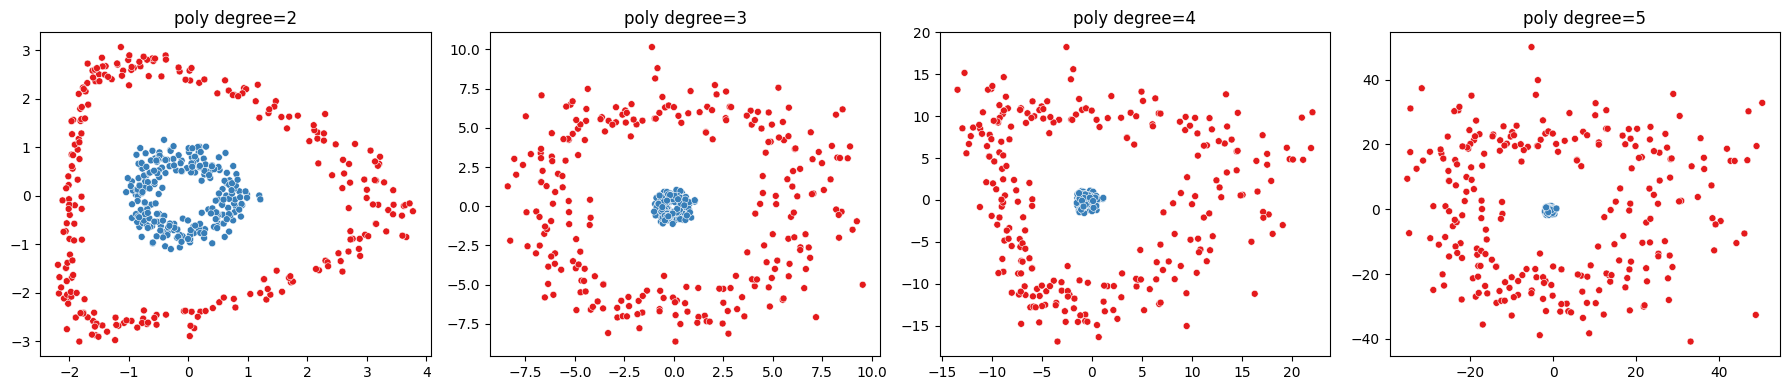

In [69]:
from sklearn.decomposition import KernelPCA
from sklearn.datasets import make_circles

X_k, y_k = make_circles(n_samples=500, factor=0.3, noise=0.06, random_state=42)
X_k_scaled = StandardScaler().fit_transform(X_k)

degrees = [2, 3, 4, 5]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, degree in zip(axes, degrees):
    kpca_poly = KernelPCA(n_components=2, kernel="poly", degree=degree, gamma=1.0)
    X_kp = kpca_poly.fit_transform(X_k_scaled)
    sns.scatterplot(x=X_kp[:, 0], y=X_kp[:, 1], hue=y_k, palette="Set1", s=25, ax=ax, legend=False)
    ax.set_title(f"poly degree={degree}")

plt.tight_layout()
plt.show()

# 7

In [70]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score

digits = load_digits()
X_cls = digits.data
y_cls = digits.target

X_cls_scaled = StandardScaler().fit_transform(X_cls)

X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_cls_scaled)
X_lda2 = LDA(n_components=2).fit_transform(X_cls_scaled, y_cls)
X_tsne2 = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_cls_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_cls_scaled, y_cls, test_size=0.25, random_state=42, stratify=y_cls)

def reduced_accuracy(transformer_name):
    if transformer_name == "PCA":
        tr = PCA(n_components=2, random_state=42)
        Xtr = tr.fit_transform(X_train)
        Xte = tr.transform(X_test)
    elif transformer_name == "LDA":
        tr = LDA(n_components=2)
        Xtr = tr.fit_transform(X_train, y_train)
        Xte = tr.transform(X_test)
    else:
        tr_train = TSNE(n_components=2, random_state=42, perplexity=30)
        Xtr = tr_train.fit_transform(X_train)
        tr_test = TSNE(n_components=2, random_state=42, perplexity=30)
        Xte = tr_test.fit_transform(X_test)

    clf = LogisticRegression(max_iter=5000)
    clf.fit(Xtr, y_train)
    return accuracy_score(y_test, clf.predict(Xte))

print("Accuracy with 2D representation:")
for name in ["PCA", "LDA", "TSNE"]:
    print(f"{name}: {reduced_accuracy(name):.4f}")

Accuracy with 2D representation:
PCA: 0.5156
LDA: 0.7156
TSNE: 0.0978


# 8

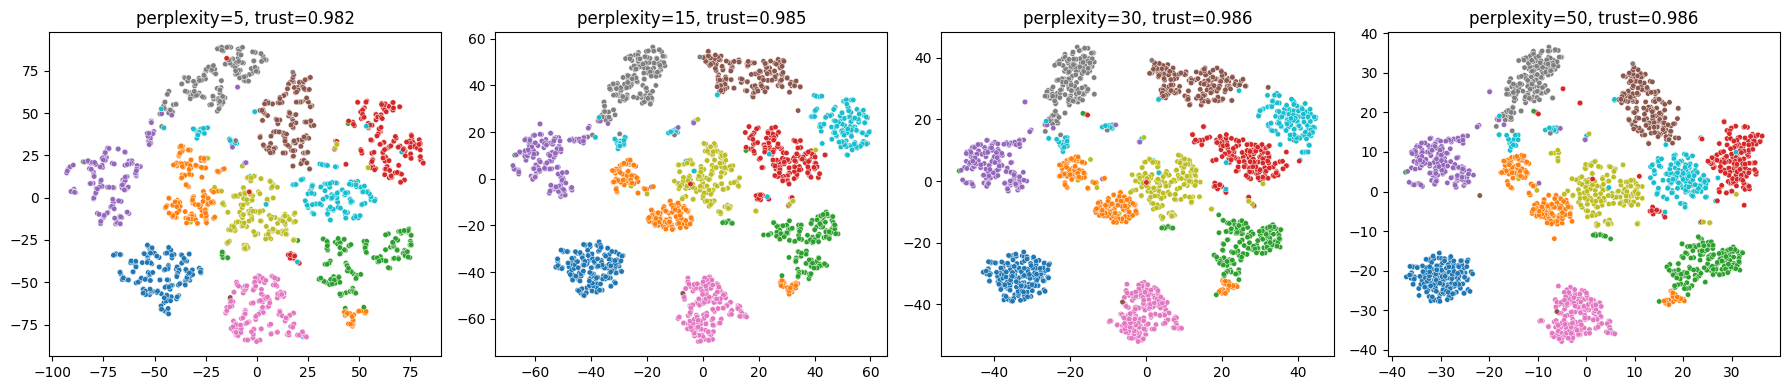

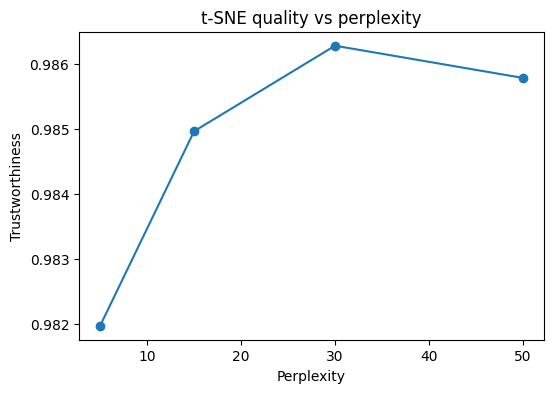

In [71]:
from sklearn.manifold import trustworthiness

perplexities = [5, 15, 30, 50]
trust_scores = []

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, p in zip(axes, perplexities):
    X_emb = TSNE(n_components=2, perplexity=p, random_state=42).fit_transform(X_cls_scaled)
    tw = trustworthiness(X_cls_scaled, X_emb, n_neighbors=10)
    trust_scores.append(tw)

    sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=y_cls, palette="tab10", s=15, ax=ax, legend=False)
    ax.set_title(f"perplexity={p}, trust={tw:.3f}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(perplexities, trust_scores, marker="o")
plt.xlabel("Perplexity")
plt.ylabel("Trustworthiness")
plt.title("t-SNE quality vs perplexity")
plt.show()

# 9

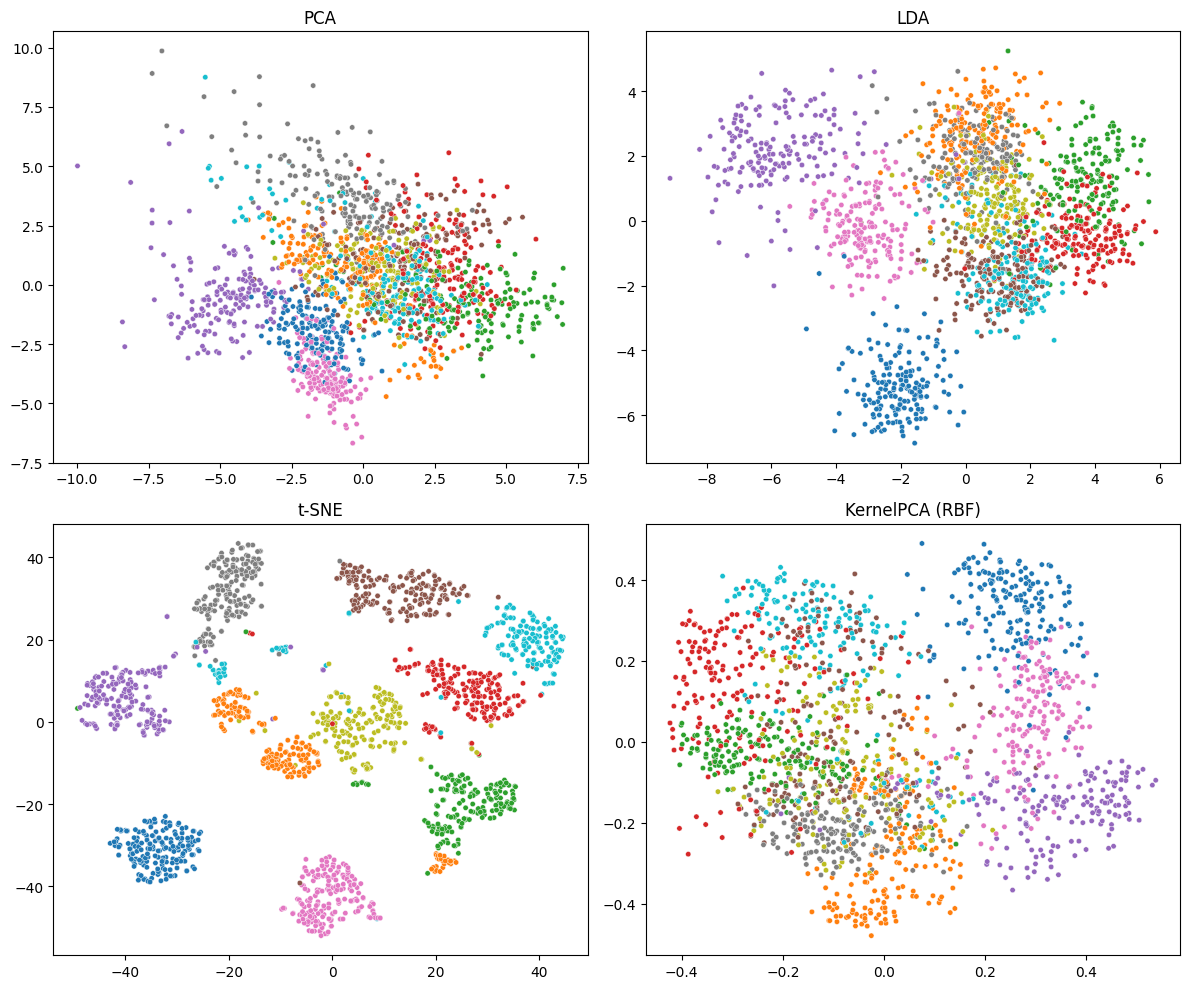

In [72]:
X_kpca2 = KernelPCA(n_components=2, kernel="rbf", gamma=0.01).fit_transform(X_cls_scaled)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=y_cls, palette="tab10", s=15, ax=ax[0, 0], legend=False)
ax[0, 0].set_title("PCA")

sns.scatterplot(x=X_lda2[:, 0], y=X_lda2[:, 1], hue=y_cls, palette="tab10", s=15, ax=ax[0, 1], legend=False)
ax[0, 1].set_title("LDA")

sns.scatterplot(x=X_tsne2[:, 0], y=X_tsne2[:, 1], hue=y_cls, palette="tab10", s=15, ax=ax[1, 0], legend=False)
ax[1, 0].set_title("t-SNE")

sns.scatterplot(x=X_kpca2[:, 0], y=X_kpca2[:, 1], hue=y_cls, palette="tab10", s=15, ax=ax[1, 1], legend=False)
ax[1, 1].set_title("KernelPCA (RBF)")

plt.tight_layout()
plt.show()

# 10

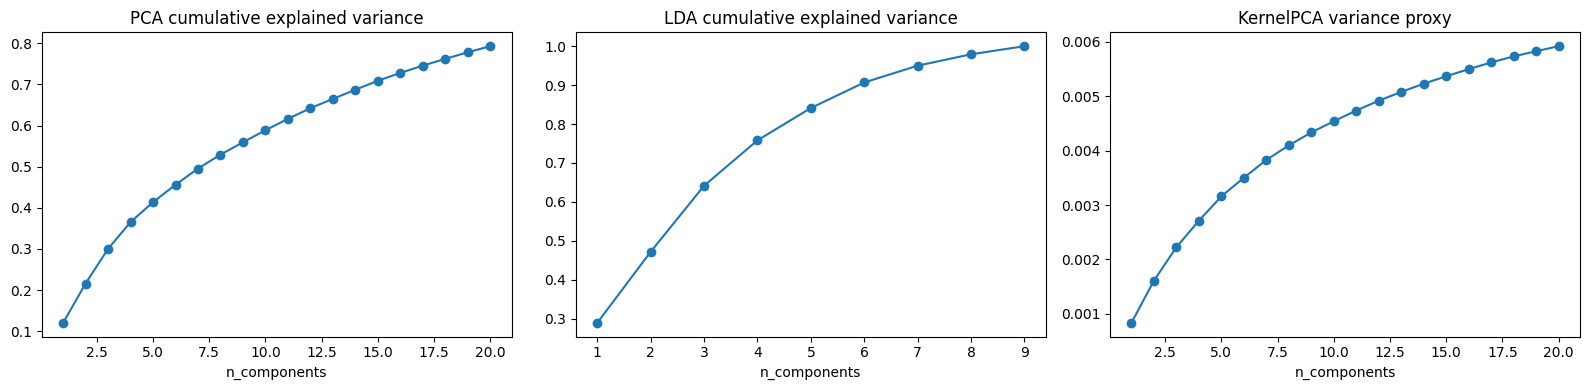

Elbow-like optimal components: PCA=20, LDA=9, KernelPCA=20


In [73]:
def transformed_variance_ratio(X_transformed, X_reference):
    return np.var(X_transformed, axis=0).sum() / np.var(X_reference, axis=0).sum()

pca_dims = range(1, 21)
lda_dims = range(1, min(len(np.unique(y_cls)) - 1, X_cls_scaled.shape[1]) + 1)
kpca_dims = range(1, 21)

pca_curve = []
for d in pca_dims:
    p = PCA(n_components=d, random_state=42).fit(X_cls_scaled)
    pca_curve.append(p.explained_variance_ratio_.sum())

lda_curve = []
for d in lda_dims:
    l = LDA(n_components=d).fit(X_cls_scaled, y_cls)
    lda_curve.append(l.explained_variance_ratio_.sum())

kpca_curve = []
for d in kpca_dims:
    k = KernelPCA(n_components=d, kernel="rbf", gamma=0.01)
    X_kd = k.fit_transform(X_cls_scaled)
    kpca_curve.append(transformed_variance_ratio(X_kd, X_cls_scaled))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(list(pca_dims), pca_curve, marker="o")
ax[0].set_title("PCA cumulative explained variance")
ax[0].set_xlabel("n_components")

ax[1].plot(list(lda_dims), lda_curve, marker="o")
ax[1].set_title("LDA cumulative explained variance")
ax[1].set_xlabel("n_components")

ax[2].plot(list(kpca_dims), kpca_curve, marker="o")
ax[2].set_title("KernelPCA variance proxy")
ax[2].set_xlabel("n_components")

plt.tight_layout()
plt.show()

pca_opt = int(np.argmax(np.gradient(np.gradient(pca_curve))) + 1)
kpca_opt = int(np.argmax(np.gradient(np.gradient(kpca_curve))) + 1)
lda_opt = max(lda_dims)

print(f"Elbow-like optimal components: PCA={pca_opt}, LDA={lda_opt}, KernelPCA={kpca_opt}")

# 11

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)

scaler_split = StandardScaler()
X_train_scaled = scaler_split.fit_transform(X_train)
X_test_scaled = scaler_split.transform(X_test)

pca_final = PCA(n_components=pca_opt, random_state=42)
Xtr_pca = pca_final.fit_transform(X_train_scaled)
Xte_pca = pca_final.transform(X_test_scaled)
train_var_pca = pca_final.explained_variance_ratio_.sum()
test_var_pca = transformed_variance_ratio(Xte_pca, X_test_scaled)

lda_final = LDA(n_components=lda_opt)
Xtr_lda = lda_final.fit_transform(X_train_scaled, y_train)
Xte_lda = lda_final.transform(X_test_scaled)
train_var_lda = lda_final.explained_variance_ratio_.sum()
test_var_lda = transformed_variance_ratio(Xte_lda, X_test_scaled)

kpca_final = KernelPCA(n_components=kpca_opt, kernel="rbf", gamma=0.01)
Xtr_kpca = kpca_final.fit_transform(X_train_scaled)
Xte_kpca = kpca_final.transform(X_test_scaled)
train_var_kpca = transformed_variance_ratio(Xtr_kpca, X_train_scaled)
test_var_kpca = transformed_variance_ratio(Xte_kpca, X_test_scaled)

summary = pd.DataFrame(
    {
        "method": ["PCA", "LDA", "KernelPCA"],
        "train_variance_metric": [train_var_pca, train_var_lda, train_var_kpca],
        "test_variance_metric": [test_var_pca, test_var_lda, test_var_kpca],
    }
)

display(summary)

,method,train_variance_metric,test_variance_metric
0,PCA,0.791498,0.753531
1,LDA,1.000000,0.485545
2,KernelPCA,0.005919,0.004805
